
## 3. Agrupación (Clustering) — `samsung.csv`
### Algoritmo: K-Means

**Justificación del algoritmo:** `samsung.csv` contiene el histórico diario del precio de cierre (`Close`) y
el volumen negociado (`Volume`) de la acción de Samsung. No existe una etiqueta objetivo -"a diferencia del
análisis supervisado [...] en el análisis no supervisado los datos no vienen con etiquetas predefinidas"
Se eligió **K-Means** porque:
- Es el primer algoritmo de agrupación visto en clase, y es el
  practicado en los notebooks *kmeans-ventas* y *Agrupación k-means-2023*, robusto y de fácil interpretación
  para encontrar grupos ("regímenes" de comportamiento del mercado) a partir de variables numéricas.
- Se siguen los pasos vistos en clase (elegir k, asignar centroides
  aleatorios, asignar cada punto al centroide más cercano, recalcular centroides e iterar) y se respeta la
  recomendación : *"las características deben medirse en la misma escala, por lo que
  puede ser necesario realizar la estandarización"*, razón por la cual se escalan las variables antes de
  entrenar el modelo.
- Permite, mediante el método del codo, el objetivo es encontrar la k adecuada para que en
  cada clúster no aumente significativamente la varianza, se elegiría el valor donde se encuentra el
  codo y el coeficiente de silueta, determinar de forma objetiva el número óptimo de grupos.
- Al construir variables derivadas (retorno diario y volatilidad), K-Means agrupa los días de negociación en
  comportamientos similares (por ejemplo: estable, alta volatilidad, alto volumen).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set_style('whitegrid')


### Paso 1. Carga y exploración de los datos

In [2]:
DATA_DIR = os.path.join('..', '..', 'Conjunto de datos para 2a. evaluación')
datos = pd.read_csv(os.path.join(DATA_DIR, 'samsung.csv'))
datos['Date'] = pd.to_datetime(datos['Date'], format='%d/%m/%Y')
datos = datos.sort_values('Date').reset_index(drop=True)
datos.head()


,Date,Close,Volume
0,2008-01-02,10880,18047200
1,2008-01-03,10920,19346500
2,2008-01-04,10780,17997350
3,2008-01-07,10380,39787200
4,2008-01-08,10320,24783700


In [3]:
datos.describe()


,Date,Close,Volume
count,2850,2850.000000,2.850000e+03
mean,2013-09-12 15:43:49.894736640,26611.305263,1.610505e+07
min,2008-01-02 00:00:00,8040.000000,0.000000e+00
25%,2010-10-25 06:00:00,16300.000000,1.021426e+07
50%,2013-09-02 12:00:00,25600.000000,1.359033e+07
75%,2016-07-26 18:00:00,30850.000000,1.960970e+07
max,2019-06-28 00:00:00,57220.000000,6.487345e+07
std,NaN,11991.608543,8.661794e+06


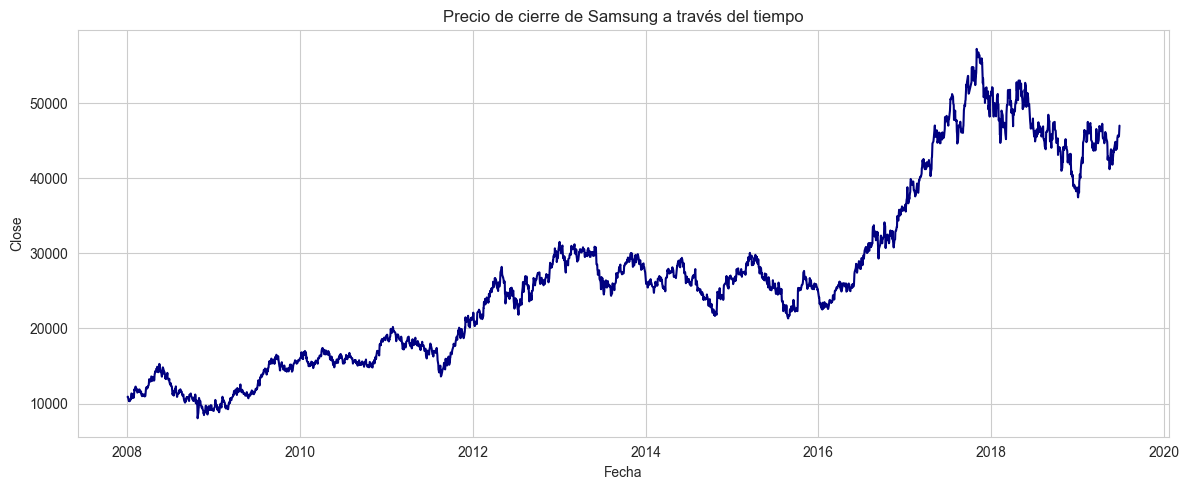

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(datos['Date'], datos['Close'], color='navy')
plt.title('Precio de cierre de Samsung a través del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Close')
plt.tight_layout()
plt.savefig('grafica_serie_tiempo_samsung.png', dpi=120)
plt.show()


### Paso 2. Ingeniería de variables (diseño del modelo)

In [5]:
datos['retorno_diario'] = datos['Close'].pct_change() * 100
datos['volatilidad_5d'] = datos['retorno_diario'].rolling(window=5).std()
datos['volumen_millones'] = datos['Volume'] / 1_000_000
datos = datos.dropna().reset_index(drop=True)
datos[['Date', 'Close', 'volumen_millones', 'retorno_diario', 'volatilidad_5d']].head()


,Date,Close,volumen_millones,retorno_diario,volatilidad_5d
0,2008-01-09,10500,23.86545,1.744186,2.032904
1,2008-01-10,10320,31.55135,-1.714286,1.974025
2,2008-01-11,10320,23.42515,0.000000,2.028308
3,2008-01-14,10500,22.16700,1.744186,1.505918
4,2008-01-15,10640,40.28395,1.333333,1.489103


Se construyeron tres variables numéricas para caracterizar el comportamiento diario de la acción:
`volumen_millones`, `retorno_diario` (variación porcentual del cierre respecto al día anterior) y
`volatilidad_5d` (desviación estándar móvil de 5 días de los retornos). Estas variables son las que
alimentarán al algoritmo de agrupación.

### Paso 3. Escalamiento de variables

In [6]:
features = ['Close', 'volumen_millones', 'retorno_diario', 'volatilidad_5d']
X = datos[features].values

scaler = StandardScaler()
X_esc = scaler.fit_transform(X)
X_esc[:5]


array([[-1.34703997,  0.89828113,  0.88445753,  0.36529026],
       [-1.36206333,  1.78635229, -0.9439027 ,  0.29743104],
       [-1.36206333,  0.84740645, -0.03762616,  0.35999285],
       [-1.34703997,  0.70203288,  0.88445753, -0.24207092],
       [-1.33535513,  2.79536492,  0.66725559, -0.26145098]])

### Paso 4. Determinación del número óptimo de clústeres

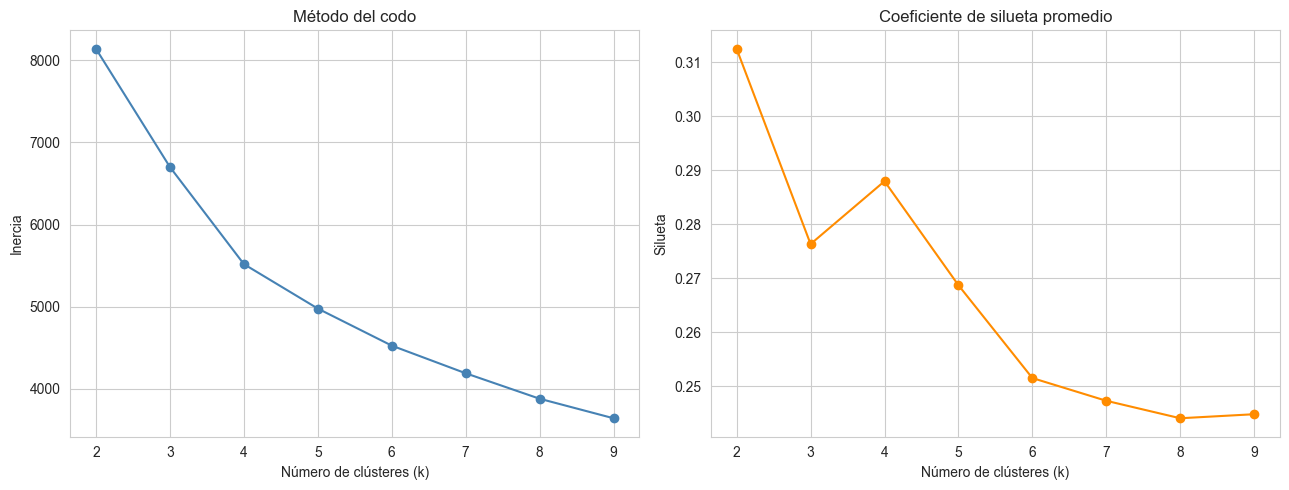

Siluetas por k: {2: np.float64(0.312), 3: np.float64(0.276), 4: np.float64(0.288), 5: np.float64(0.269), 6: np.float64(0.252), 7: np.float64(0.247), 8: np.float64(0.244), 9: np.float64(0.245)}


In [7]:
inercias = []
siluetas = []
rango_k = range(2, 10)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    etiquetas_k = km.fit_predict(X_esc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_esc, etiquetas_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(rango_k), inercias, marker='o', color='steelblue')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(rango_k), siluetas, marker='o', color='darkorange')
axes[1].set_title('Coeficiente de silueta promedio')
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Silueta')
plt.tight_layout()
plt.savefig('grafica_codo_silueta_samsung.png', dpi=120)
plt.show()

print('Siluetas por k:', dict(zip(rango_k, np.round(siluetas, 3))))


**Interpretación:** El valor de *k* elegido es el que produce un buen balance entre una silueta alta y
un codo claro en la curva de inercia (ver gráficas anteriores). Con base en ello se selecciona **k = 4** para
representar comportamientos como: mercado estable, tendencia alcista, tendencia bajista y alta volatilidad.

### Paso 5. Entrenamiento del modelo K-Means

In [8]:
K_OPTIMO = 4
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=1, n_init=10)
datos['cluster'] = kmeans.fit_predict(X_esc)

print('Silueta final:', silhouette_score(X_esc, datos['cluster']))
datos['cluster'].value_counts().sort_index()


Silueta final: 0.2879929321712229


cluster
0     339
1    1393
2     616
3     497
Name: count, dtype: int64

### Paso 6. Gráficas personalizadas e interpretación de resultados

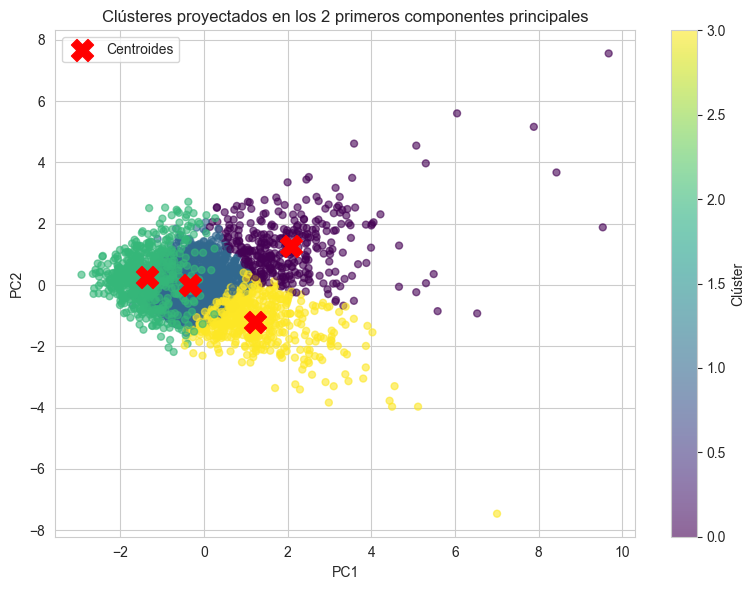

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_esc)
centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=datos['cluster'], cmap='viridis', alpha=0.6, s=25)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], marker='X', s=250, c='red', label='Centroides')
plt.title('Clústeres proyectados en los 2 primeros componentes principales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter, label='Clúster')
plt.tight_layout()
plt.savefig('grafica_pca_clusters_samsung.png', dpi=120)
plt.show()


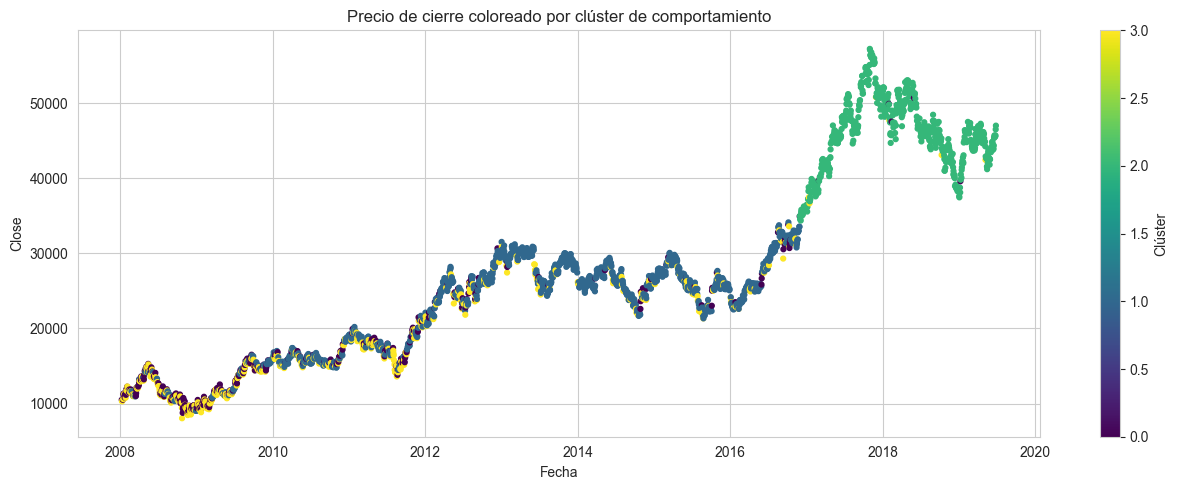

In [10]:
plt.figure(figsize=(13, 5))
scatter = plt.scatter(datos['Date'], datos['Close'], c=datos['cluster'], cmap='viridis', s=12)
plt.title('Precio de cierre coloreado por clúster de comportamiento')
plt.xlabel('Fecha')
plt.ylabel('Close')
plt.colorbar(scatter, label='Clúster')
plt.tight_layout()
plt.savefig('grafica_serie_tiempo_clusters_samsung.png', dpi=120)
plt.show()


In [11]:
perfil_clusters = datos.groupby('cluster')[features].mean()
perfil_clusters


,Close,volumen_millones,retorno_diario,volatilidad_5d
cluster,,,,
0,16662.418879,28.253503,2.689121,2.739941
1,23890.423546,12.535421,0.208671,1.382572
2,45823.360390,11.516435,0.074472,1.463471
3,17371.891348,23.431636,-2.103984,2.264851


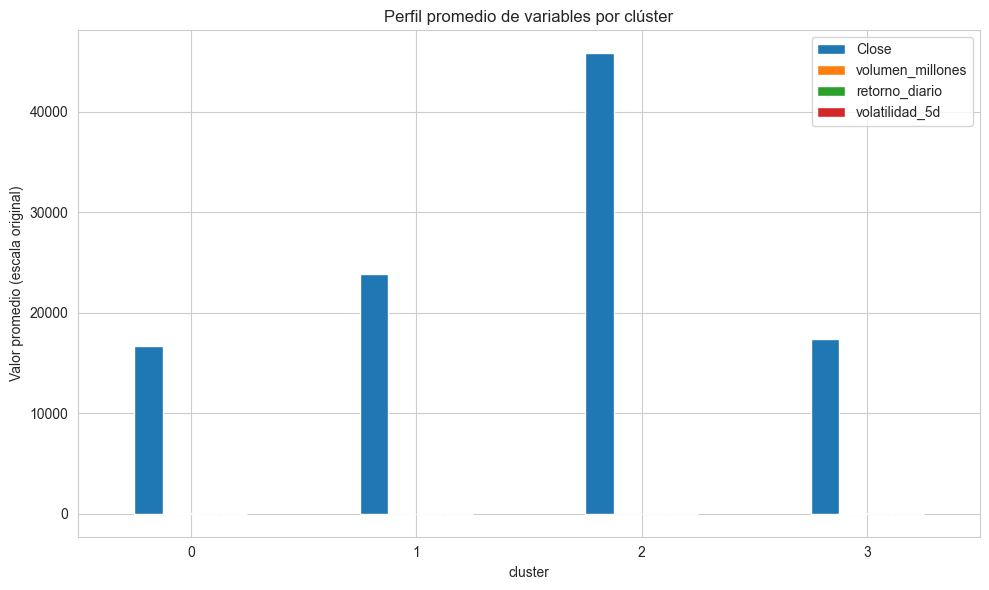

In [12]:
perfil_clusters.plot(kind='bar', figsize=(10, 6), subplots=False)
plt.title('Perfil promedio de variables por clúster')
plt.ylabel('Valor promedio (escala original)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafica_perfil_clusters_samsung.png', dpi=120)
plt.show()


### Paso 7. Optimización del modelo

In [13]:
for k in [3, 4, 5, 6]:
    km_tmp = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_esc)
    print(f'k={k} -> inercia={km_tmp.inertia_:.2f}  silueta={silhouette_score(X_esc, labels_tmp):.3f}')


k=3 -> inercia=6699.09  silueta=0.276
k=4 -> inercia=5517.99  silueta=0.288


k=5 -> inercia=4977.05  silueta=0.269
k=6 -> inercia=4526.24  silueta=0.252


**Optimización:** Se evaluaron distintos valores de *k* comparando inercia y coeficiente de silueta
(métricas de agrupación, ya que al no existir etiquetas no se pueden usar métricas supervisadas como
accuracy). El valor **k = 4** ofrece el mejor equilibrio entre compacidad de los clústeres y separación entre
ellos, por lo que se mantiene como configuración final del modelo.

## Conclusión / Interpretación final
Los clústeres obtenidos agrupan los días de negociación de Samsung según su nivel de precio, volumen y
volatilidad. Esto permite identificar visualmente periodos de mercado con comportamiento similar (por
ejemplo, etapas de alta volatilidad frente a etapas estables), información útil para análisis financiero.

**Enlace al repositorio con el modelo:** https://github.com/YosueCh/2a.-Evaluaci-n-Extracci-n-de-conocimiento-en-bases-de-datos.git
